In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Get from LHE

Reads the LHE files in order to get the known valid points, getting the the list of important parameters

In [2]:
import os
import glob
import re
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
DATA_DIR = "valid_points_lhe"    # Carpeta con archivos .lha
OUTPUT_CSV = "valid_points_extended.csv"

# ─────────────────────────────────────────────────────────────────────────────
# MAPEO DE PDG IDs A NOMBRES (Para columnas legibles)
# ─────────────────────────────────────────────────────────────────────────────
PDG_MAP = {
    1: "d",  2: "u",  3: "s",  4: "c",  5: "b",  6: "t",
    11: "e", 12: "nue", 13: "mu", 14: "numu", 15: "ta", 16: "nuta",
    21: "g", 22: "ga", 23: "Z", 24: "W",
    25: "h1", 35: "h2", 36: "A", 37: "Hp"
}

def get_particle_name(pid):
    """Devuelve el nombre de la partícula o el ID si no está en el mapa."""
    # Usamos abs() porque 5 y -5 son ambos 'b' para efectos del nombre del canal
    pid = abs(int(pid)) 
    return PDG_MAP.get(pid, str(pid))

# ─────────────────────────────────────────────────────────────────────────────
# REGEX PARA BLOQUES (MINPAR/MASS)
# ─────────────────────────────────────────────────────────────────────────────
line_re = re.compile(r'^\s*(\d+)\s+([+-]?\d*\.\d+(?:[eE][+-]?\d+)?)\s*#\s*(.+)$')

# ─────────────────────────────────────────────────────────────────────────────
# MAPAS DE BLOQUES EXISTENTES
# ─────────────────────────────────────────────────────────────────────────────
MINPAR_MAP = {
    3:  "tan_beta",
    11: "lambda1", 12: "lambda2", 13: "lambda3", 14: "lambda4",
    15: "lambda5", 16: "lambda6", 17: "lambda7",
    18: "m12_2",   20: "sin_ba",  21: "cos_ba",  24: "yukawa_type",
}
MASS_MAP = {
    25: "Mh1", 35: "Mh2", 36: "Mh3", 37: "MHp"
}

# ─────────────────────────────────────────────────────────────────────────────
# LOOP PRINCIPAL
# ─────────────────────────────────────────────────────────────────────────────
records = []

print(f"Procesando archivos en: {DATA_DIR} ...")

for path in sorted(glob.glob(os.path.join(DATA_DIR, "*.lha"))):
    rec = {"file": os.path.basename(path)}
    current_block = None
    
    with open(path) as f:
        for line in f:
            line_strip = line.strip()
            up = line_strip.upper()
            
            # 1. DETECCIÓN DE BLOQUES Y DECAYS
            if up.startswith("BLOCK MINPAR"):
                current_block = "MINPAR"
                continue
            elif up.startswith("BLOCK MASS"):
                current_block = "MASS"
                continue
            # Detectar inicio de DECAY 35 (h2)
            elif up.startswith("DECAY  35") or up.startswith("DECAY 35"):
                current_block = "DECAY_35"
                # Opcional: Extraer el width total de esta misma línea si lo necesitas
                # parts = line_strip.split()
                # rec["Width_h2"] = float(parts[2])
                continue
            # Si empieza otro BLOCK o DECAY, salimos del estado actual
            elif up.startswith("BLOCK") or up.startswith("DECAY"):
                current_block = None
                continue

            # 2. PROCESAMIENTO SEGÚN EL BLOQUE ACTUAL
            
            # --- Bloques de Parámetros (MINPAR, MASS) ---
            if current_block in ("MINPAR", "MASS"):
                m = line_re.match(line)
                if m:
                    code = int(m.group(1))
                    val  = float(m.group(2))
                    if current_block == "MINPAR" and code in MINPAR_MAP:
                        rec[MINPAR_MAP[code]] = val
                    elif current_block == "MASS" and code in MASS_MAP:
                        rec[MASS_MAP[code]] = val
            
            # --- Bloque de Decaimiento h2 (DECAY 35) ---
            elif current_block == "DECAY_35":
                # Ignorar comentarios dentro del bloque
                if line_strip.startswith("#") or not line_strip:
                    continue
                
                # Formato típico: BR  NDA  ID1  ID2
                parts = line_strip.split()
                
                # Necesitamos al menos 4 columnas (BR, NDA, ID1, ID2)
                if len(parts) >= 4:
                    try:
                        br = float(parts[0])
                        # nda = int(parts[1]) # No lo usamos por ahora
                        id1 = parts[2]
                        id2 = parts[3]
                        
                        # Construir nombre de columna: Ej. BR_h2_bb, BR_h2_ta_ta
                        p1_name = get_particle_name(id1)
                        p2_name = get_particle_name(id2)
                        
                        # Ordenamos nombres alfabéticamente para evitar duplicados (ej: W+ W- vs W- W+)
                        # Aunque en 2HDMC suelen venir ordenados, es buena práctica.
                        channel_suffix = "_".join(sorted([p1_name, p2_name]))
                        col_name = f"BR_h2_{channel_suffix}"
                        
                        rec[col_name] = br
                    except ValueError:
                        continue # Saltamos líneas que no se puedan parsear

    records.append(rec)

# ─────────────────────────────────────────────────────────────────────────────
# CREACIÓN DEL DATAFRAME
# ─────────────────────────────────────────────────────────────────────────────
df = pd.DataFrame(records)

# Filtrar si es necesario (ej: Mh1 == 125)
# df = df[ (df['Mh1'] > 124) & (df['Mh1'] < 126) ]

# Reordenar columnas: Poner File y Parámetros primero, luego BRs
base_cols = ["file"] + list(MINPAR_MAP.values()) + list(MASS_MAP.values())
# Identificar columnas de BR dinámicamente (las que no son base)
br_cols = [c for c in df.columns if c not in base_cols]
# Ordenar BRs alfabéticamente para consistencia
br_cols.sort()

# Reindexar final (rellenando NaNs con 0.0 para BRs que no existan en algunos archivos)
final_cols = base_cols + br_cols
df = df.reindex(columns=final_cols)

# Para los BRs, si un canal no existe en el archivo, el BR es 0, no NaN
df[br_cols] = df[br_cols].fillna(0.0)

print(f"Extracción completada. Columnas encontradas: {len(df.columns)}")
print(df.head())


Procesando archivos en: valid_points_lhe ...
Extracción completada. Columnas encontradas: 29
      file  tan_beta   lambda1   lambda2   lambda3   lambda4   lambda5  \
0  100.lha   10000.0  1.134423  0.257734  2.896938 -1.319617 -1.319617   
1  110.lha   10000.0  1.099787  0.257734  2.827659 -1.284978 -1.284978   
2  120.lha   10000.0  1.061852  0.257734  2.751782 -1.247039 -1.247039   
3  130.lha   10000.0  1.020619  0.257734  2.669307 -1.205802 -1.205802   
4  140.lha   10000.0  0.976086  0.257734  2.580235 -1.161265 -1.161265   

   lambda6  lambda7     m12_2  ...  BR_h2_Z_ga  BR_h2_b_b  BR_h2_c_c  \
0      0.1      0.0  0.999909  ...    0.001390   0.616527   0.027670   
1      0.1      0.0  1.209909  ...    0.001391   0.616523   0.027670   
2      0.1      0.0  1.439909  ...    0.001392   0.616519   0.027670   
3      0.1      0.0  1.689909  ...    0.055195   0.392524   0.017606   
4      0.1      0.0  1.959909  ...    0.084123   0.346920   0.015545   

      BR_h2_e_e  BR_h2_g_g  B

In [3]:
# comprobación
df[['BR_h2_W_W', 'BR_h2_Z_Z',
       'BR_h2_Z_ga', 'BR_h2_b_b', 'BR_h2_c_c', 'BR_h2_e_e', 'BR_h2_g_g',
       'BR_h2_ga_ga', 'BR_h2_mu_mu', 'BR_h2_s_s', 'BR_h2_t_t', 'BR_h2_ta_ta']].sum(axis=1)

0     1.0
1     1.0
2     1.0
3     1.0
4     1.0
5     1.0
6     1.0
7     1.0
8     1.0
9     1.0
10    1.0
11    1.0
12    1.0
13    1.0
14    1.0
15    1.0
16    1.0
17    1.0
18    1.0
19    1.0
20    1.0
21    1.0
22    1.0
dtype: float64

In [4]:
# ----- -set de values- ---------
cols = ['tan_beta','lambda6', 'lambda7', 'sin_ba',
       'yukawa_type', 'Mh3', 'MHp']
# calcular el set de valores de cada columna
values_set = {col: set(df[col].dropna().unique()) for col in cols}
values_set

# se encuentra que hay un dato sin_ba que es 0, algun typo?

{'tan_beta': {np.float64(10000.0)},
 'lambda6': {np.float64(0.1)},
 'lambda7': {np.float64(0.0)},
 'sin_ba': {np.float64(0.0), np.float64(1.0)},
 'yukawa_type': set(),
 'Mh3': {np.float64(300.0)},
 'MHp': {np.float64(300.0)}}

In [5]:
# solo se encuentran en las regiones
# donde m_phi < 125
# por convención es correcto
df[df['sin_ba']==0]

,file,tan_beta,lambda1,lambda2,lambda3,lambda4,lambda5,lambda6,lambda7,m12_2,...,BR_h2_Z_ga,BR_h2_b_b,BR_h2_c_c,BR_h2_e_e,BR_h2_g_g,BR_h2_ga_ga,BR_h2_mu_mu,BR_h2_s_s,BR_h2_t_t,BR_h2_ta_ta
0,100.lha,10000.0,1.134423,0.257734,2.896938,-1.319617,-1.319617,0.1,0.0,0.999909,...,0.001390,0.616527,0.027670,4.938041e-09,0.073424,0.001967,0.000211,0.000225,0.0,0.059633
1,110.lha,10000.0,1.099787,0.257734,2.827659,-1.284978,-1.284978,0.1,0.0,1.209909,...,0.001391,0.616523,0.027670,4.938010e-09,0.073424,0.001972,0.000211,0.000225,0.0,0.059632
2,120.lha,10000.0,1.061852,0.257734,2.751782,-1.247039,-1.247039,0.1,0.0,1.439909,...,0.001392,0.616519,0.027670,4.937976e-09,0.073424,0.001978,0.000211,0.000225,0.0,0.059632
21,80.lha,10000.0,1.193799,0.257734,3.015702,-1.378999,-1.378999,0.1,0.0,0.639909,...,0.001388,0.616533,0.027671,4.938094e-09,0.073425,0.001959,0.000211,0.000225,0.0,0.059633
22,90.lha,10000.0,1.165760,0.257734,2.959619,-1.350957,-1.350957,0.1,0.0,0.809909,...,0.001389,0.616530,0.027671,4.938069e-09,0.073425,0.001963,0.000211,0.000225,0.0,0.059633


In [6]:
# ---- filtrado ----
df = df[df['sin_ba']!=0]

In [7]:
# get beta
df['beta'] = pd.Series([np.arctan(tb) for tb in df['tan_beta']])
df['sin_beta'] = np.sin(df['beta'])
df['cos_beta'] = np.cos(df['beta'])


In [18]:
print(df.head())

      file  tan_beta   lambda1   lambda2   lambda3   lambda4   lambda5  \
3  130.lha   10000.0  1.020619  0.257734  2.669307 -1.205802 -1.205802   
4  140.lha   10000.0  0.976086  0.257734  2.580235 -1.161265 -1.161265   
5  150.lha   10000.0  0.928255  0.257734  2.484564 -1.113430 -1.113430   
6  160.lha   10000.0  0.877126  0.257734  2.382295 -1.062296 -1.062296   
7  170.lha   10000.0  0.822698  0.257734  2.273428 -1.007862 -1.007862   

   lambda6  lambda7     m12_2  ...  BR_h2_g_g  BR_h2_ga_ga  BR_h2_mu_mu  \
3      0.1      0.0  1.689909  ...   0.050770     0.445387     0.000135   
4      0.1      0.0  1.959909  ...   0.052523     0.466389     0.000121   
5      0.1      0.0  2.249909  ...   0.053702     0.481950     0.000108   
6      0.1      0.0  2.559909  ...   0.054452     0.493267     0.000096   
7      0.1      0.0  2.889909  ...   0.054898     0.501370     0.000086   

   BR_h2_s_s  BR_h2_t_t  BR_h2_ta_ta      beta  sin_beta  cos_beta  \
3   0.000143        0.0     0.0382

Procedemos a calcular $\bar m^2$ la cual es la variable fundamental
$$
\bar m^2 = \frac{m_{12}^2}{\sin \beta \cos \beta}
$$

In [9]:
df['mbar'] = df['m12_2'] / ( df['sin_beta'] * df['cos_beta'] )

(array([5., 4., 3., 3.]),
 array([16899.09016897, 30899.09030896, 44899.09044895, 58899.09058894,
        72899.09072892]),
 <BarContainer object of 4 artists>)

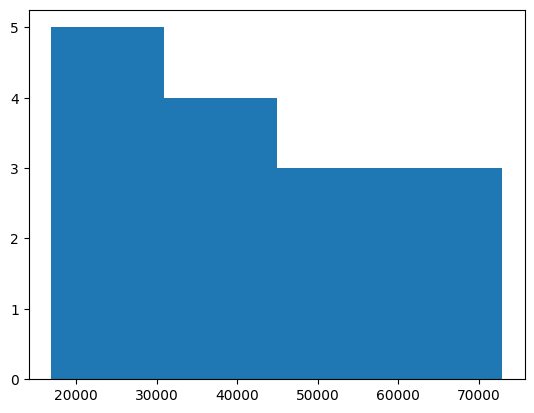

In [10]:
# los valores de m_bar en este casoson bastante aleatorios
plt.hist(df['mbar'], bins=int(np.sqrt(len(df))))

# Como calza con las expresiones analiticas?

In [11]:

from lib.utils import estimate_exploration_time, expand_parameter_space
import numpy as np
import matplotlib.pyplot as plt

from lib.oracle import run_oracle, safe_run_oracle

def physpoint(mphi: float, m12_2: float, mA: float = 300.0, sin_ba=1, tanbeta=1e4, lambda6=0.1, lambda7=0.0):
    # Llama al modelo con valores fijos y retorna el diccionario de resultados
    return safe_run_oracle([mphi, mA, sin_ba, tanbeta, lambda6, lambda7, m12_2])


In [12]:
# diccionario de valores m_phi y m_12_2
points = {
    'mphi': df.Mh2,
    'm12_2': df.m12_2
}

In [13]:
# select point with key 0


In [14]:
physpoint(points['mphi'][5], points['m12_2'][5])

{'positivity_ok': 1,
 'unitarity_ok': 1,
 'perturbativity_ok': 1,
 'w_h2_bb': 3.106462144734183e-11,
 'w_h2_tautau': 3.105515121386519e-12,
 'w_h2_uu': 0.0,
 'w_h2_du': 0.0,
 'w_h2_ln': 0.0,
 'w_h2_vv': [4.897942063182421e-11, 0.0, 0.0],
 'w_h2_gaga': 4.897942063182421e-11,
 'w_h2_Zga': 1.159532928540934e-11,
 'w_h2_gg': 5.45574079107875e-12,
 'w_h2_hh': 0.0,
 'w_total_h2': 1.016137419602666e-10,
 'w_total_top': 1.338069402459526,
 'branching_ratio_h2_gaga': 0.4820157164468595,
 'lambda1': 1.093205067158578,
 'lambda2': 0.2577337926166231,
 'lambda3': 2.484563759280122,
 'lambda4': -1.113429987509171,
 'lambda5': -1.113429987509171,
 'lambda6': 0.1,
 'lambda7': 0.0}

In [15]:
np_phihh = []
np_total = []
for i in points['mphi'].index:
    decays = physpoint(points['mphi'][i], points['m12_2'][i])
    phi_hh = decays['w_h2_hh']
    phi_total = decays['w_total_h2']
    np_phihh.append(phi_hh)
    np_total.append(phi_total)

np_phihh = np.array(np_phihh)
np_total = np.array(np_total)

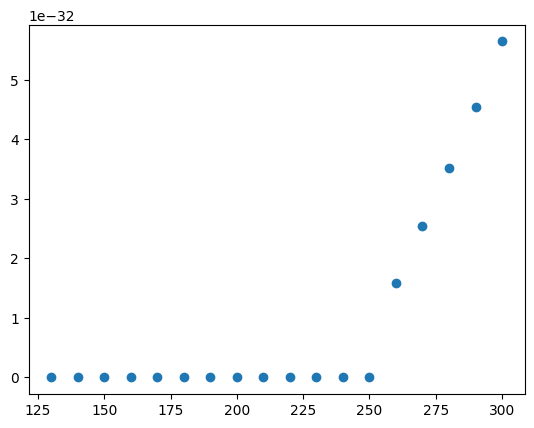

In [16]:
plt.plot(points['mphi'], np_phihh, 'o')

# Visualizar los BR presentes

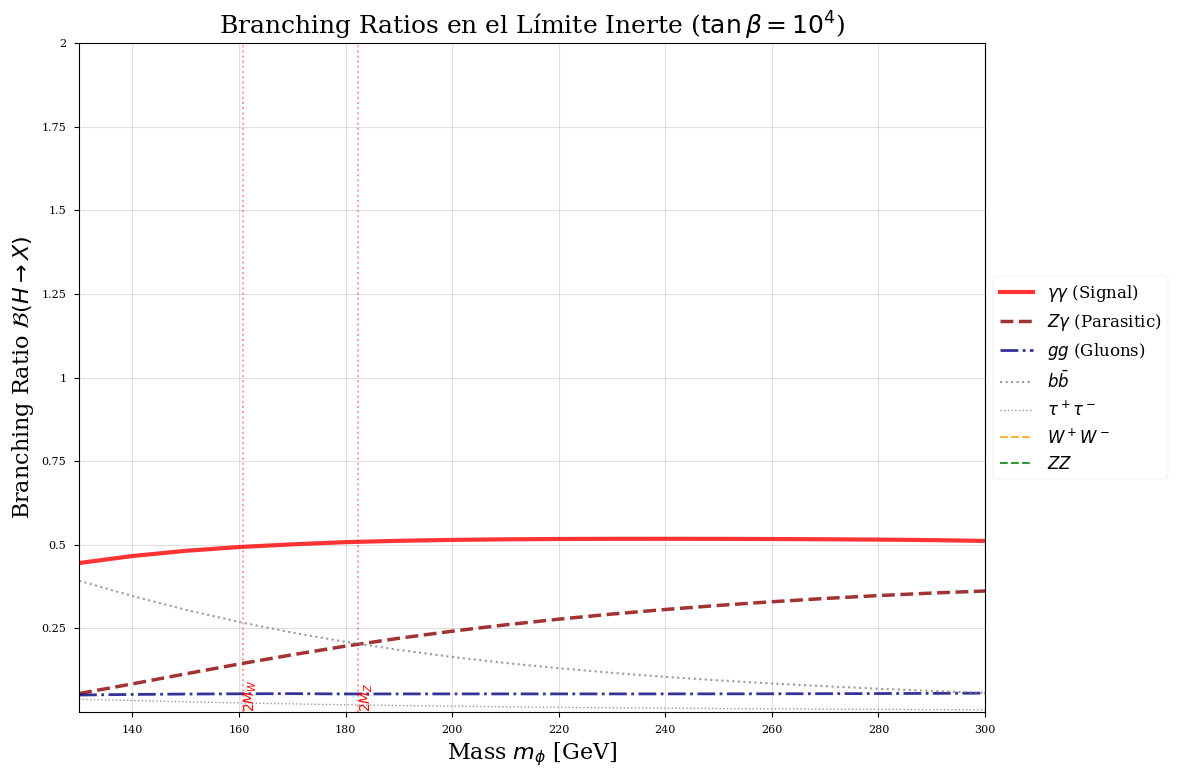

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ==========================================
# CONFIGURACIÓN DE DATOS
# ==========================================
# Asegurarnos de tener la columna 'm_phi' numérica y ordenada
if 'm_phi' not in df.columns and 'file' in df.columns:
    # Extraer numero del nombre de archivo "130.lha" -> 130.0
    df['m_phi'] = df['file'].astype(str).str.extract(r'(\d+)').astype(float)

# Ordenar por masa para que las líneas salgan bien
df_sorted = df.sort_values('m_phi').copy()

# ==========================================
# CONFIGURACIÓN DEL GRÁFICO
# ==========================================
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({'font.size': 14, 'font.family': 'serif'})

fig, ax = plt.subplots(figsize=(12, 8))

# --- DEFINICIÓN DE CANALES ---
# Agrupamos por tipo de física para asignar estilos
channels = {
    # (Nombre Columna, Etiqueta Latex, Color, Estilo, Grosor)
    
    # 1. Señal y Loop Electrodébil (Los Protagonistas)
    'BR_h2_ga_ga': (r'$\gamma\gamma$ (Signal)', 'red',      '-',  3.0),
    'BR_h2_Z_ga':  (r'$Z\gamma$ (Parasitic)', 'darkred',  '--', 2.5),
    
    # 2. Loop Hadrónico (Background difícil)
    'BR_h2_g_g':   (r'$gg$ (Gluons)',         'navy',     '-.', 2.0),
    
    # 3. Fermiones (Deberían estar muertos a tb=10^4)
    'BR_h2_b_b':   (r'$b\bar{b}$',            'gray',     ':',  1.5),
    'BR_h2_ta_ta': (r'$\tau^+\tau^-$',        'gray',     ':',  1.0),
    
    # 4. Bosones Vectoriales (Suprimidos por Alineamiento, pero cinemática importante)
    'BR_h2_W_W':   (r'$W^+W^-$',              'orange',   '--', 1.5),
    'BR_h2_Z_Z':   (r'$ZZ$',                  'green',    '--', 1.5)
}

# --- PLOTTING ---
for col, (label, color, ls, lw) in channels.items():
    if col in df_sorted.columns:
        # Filtramos ceros para evitar errores en log-scale
        mask = df_sorted[col] > 1e-9
        ax.plot(df_sorted.loc[mask, 'm_phi'], df_sorted.loc[mask, col], 
                label=label, color=color, linestyle=ls, linewidth=lw, alpha=0.8)

# --- DECORACIÓN CIENTÍFICA ---
# ax.set_yscale('log')
ax.set_xlim(df_sorted['m_phi'].min(), df_sorted['m_phi'].max())
ax.set_ylim(1e-5, 2.0) # Ajustar para ver bien los cruces

# Umbrales Cinemáticos (Líneas verticales grises)
# Masa W ~ 80.4, Masa Z ~ 91.2
thresholds = {
    r'$2M_W$': 2 * 80.379,
    r'$2M_Z$': 2 * 91.1876
}

for label, val in thresholds.items():
    if val >= df_sorted['m_phi'].min() and val <= df_sorted['m_phi'].max():
        ax.axvline(val, color='red', linestyle=':', alpha=0.4)
        ax.text(val, 2e-5, label, rotation=90, verticalalignment='bottom', fontsize=10, color='red')

# Etiquetas
ax.set_xlabel(r'Mass $m_\phi$ [GeV]', fontsize=16)
ax.set_ylabel(r'Branching Ratio $\mathcal{B}(H \to X)$', fontsize=16)
ax.set_title(r'Branching Ratios en el Límite Inerte ($\tan\beta = 10^4$)', fontsize=18)

# Leyenda
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12, frameon=True)

# Grids
ax.grid(True, which="major", ls="-", alpha=0.4)
ax.grid(True, which="minor", ls=":", alpha=0.2)

# Formato Y
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))

plt.tight_layout()
plt.show()

## Variabilidad entre Oracle y Datos Calculados

Vamos a hacer una comparativa para ver si el mashep puede modificarnos datos.

Ejecutando oráculo para validación cruzada...


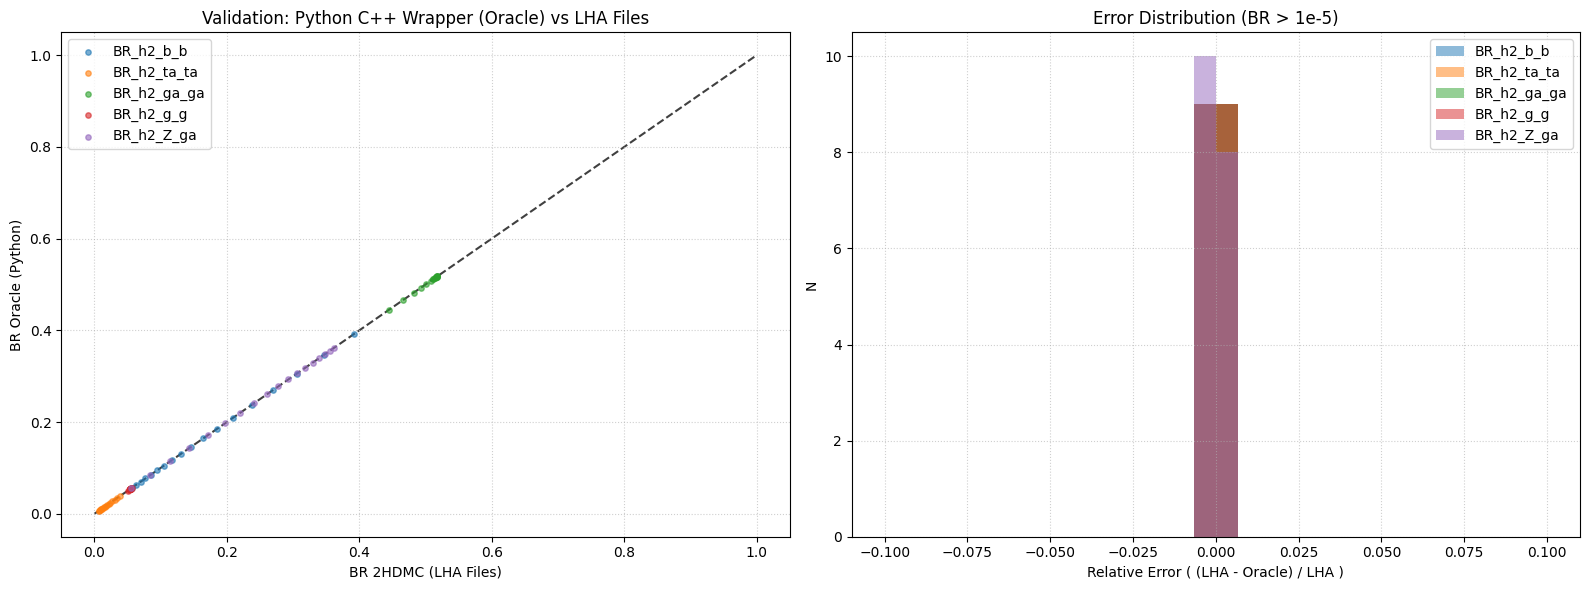


--- REPORTE DE DESVIACIONES ---
Canal BR_h2_b_b       | MAE: 1.45e-05
Canal BR_h2_ta_ta     | MAE: 1.50e-06
Canal BR_h2_ga_ga     | MAE: 1.57e-05
Canal BR_h2_g_g       | MAE: 4.56e-06
Canal BR_h2_Z_ga      | MAE: 5.61e-06


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lib.oracle import safe_run_oracle # Asumiendo que esta es tu importación

# ─────────────────────────────────────────────────────────────────────────────
# 1. CONFIGURACIÓN DEL MAPEO (Oracle Key -> DataFrame Column)
# ─────────────────────────────────────────────────────────────────────────────
# Clave del dict del Oracle : Sufijo de la columna en tu DF (ajustado al paso anterior)
# Nota: Ajusta los nombres de la derecha según como quedaron en tu CSV 'valid_points_extended.csv'
COMPARISON_MAP = {
    'w_h2_bb':      'BR_h2_b_b',
    'w_h2_tautau':  'BR_h2_ta_ta',
    'w_h2_gaga':    'BR_h2_ga_ga',
    'w_h2_gg':      'BR_h2_g_g',
    'w_h2_Zga':     'BR_h2_Z_ga',
    # Nota sobre 'vv': El oracle devuelve una lista, requiere tratamiento especial.
    # Si w_h2_vv[0] es WW y w_h2_vv[1] es ZZ (o viceversa), hay que verificarlo.
    # Por ahora omitimos vectores masivos para evitar errores de índice sin saber la estructura de tu lista.
}

# ─────────────────────────────────────────────────────────────────────────────
# 2. GENERACIÓN DE PREDICCIONES
# ─────────────────────────────────────────────────────────────────────────────
print("Ejecutando oráculo para validación cruzada...")

predictions = []

for idx, row in df.iterrows():
    # ⚠️ CRÍTICO: Asegúrate de pasar TODOS los parámetros que varían en tu DF.
    # Si tanbeta, sin_ba, etc., cambian fila a fila, debes pasarlos aquí.
    # Basado en tu ejemplo, paso los mínimos, pero dejo comentados los otros.
    
    # Extraer valores de la fila actual del DF
    mphi_val  = row['Mh2']
    m12_2_val = row['m12_2']
    
    # Si estos varían en tu DF, descomenta y úsalos:
    # ma_val      = row['Mh3']      # Asumiendo que mA es Mh3
    # tanbeta_val = row['tan_beta']
    # sin_ba_val  = row['sin_ba']
    # l6_val      = row['lambda6']
    # l7_val      = row['lambda7']

    # Llamada al oráculo (Ajusta los argumentos según la firma real de tu función)
    # Usamos try/except por si el oráculo falla en algún punto físico
    try:
        # AQUÍ ESTOY USANDO LOS VALORES POR DEFECTO DEL EJEMPLO PARA LOS NO-ESPECIFICADOS
        # DEBES ACTUALIZAR ESTO SI TUS DATOS TIENEN TANBETA VARIABLE
        res = safe_run_oracle([
            mphi_val, 
            300.0,   # mA (fijo según tu ejemplo, cambiar si es variable)
            1.0,     # sin_ba
            10000.0, # tanbeta
            0.1,     # lambda6
            0.0,     # lambda7
            m12_2_val
        ])
        
        # Calcular Branching Ratios Predichos
        w_total = res['w_total_h2']
        pred_row = {'index': idx, 'w_total_oracle': w_total}
        
        if w_total > 0:
            for oracle_key, df_col in COMPARISON_MAP.items():
                if oracle_key in res:
                    # BR = width_parcial / width_total
                    pred_row[f"PRED_{df_col}"] = res[oracle_key] / w_total
        
        predictions.append(pred_row)
        
    except Exception as e:
        print(f"Error en fila {idx}: {e}")

# Crear DF de predicciones
df_pred = pd.DataFrame(predictions).set_index('index')

# Unir con el DF original (inner join por índice)
df_merged = df.join(df_pred)

# ─────────────────────────────────────────────────────────────────────────────
# 3. ANÁLISIS NUMÉRICO Y VISUALIZACIÓN
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Definir qué canales graficar
channels_to_plot = list(COMPARISON_MAP.values())

# --- Gráfico 1: Correlación (Diagonal Plot) ---
ax = axes[0]
for col in channels_to_plot:
    pred_col = f"PRED_{col}"
    if pred_col in df_merged.columns:
        ax.scatter(df_merged[col], df_merged[pred_col], label=col, alpha=0.6, s=15)

# Línea de identidad perfecta
lims = [0, 1] # BR va de 0 a 1
ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0)
ax.set_xlabel('BR 2HDMC (LHA Files)')
ax.set_ylabel('BR Oracle (Python)')
ax.set_title('Validation: Python C++ Wrapper (Oracle) vs LHA Files')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)

# --- Gráfico 2: Residuales Relativos ((Obs - Pred) / Obs) ---
ax = axes[1]
for col in channels_to_plot:
    pred_col = f"PRED_{col}"
    if pred_col in df_merged.columns:
        # Calcular error relativo (evitando división por cero)
        # Filtramos donde el BR es significativo (> 1e-5) para evitar ruido numérico
        mask = df_merged[col] > 1e-5
        if mask.sum() > 0:
            rel_error = (df_merged.loc[mask, col] - df_merged.loc[mask, pred_col]) / df_merged.loc[mask, col]
            ax.hist(rel_error, bins=30, alpha=0.5, label=col, range=(-0.1, 0.1))

ax.set_xlabel('Relative Error ( (LHA - Oracle) / LHA )')
ax.set_ylabel('N')
ax.set_title('Error Distribution (BR > 1e-5)')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 4. REPORTE DE ERRORES MAYORES
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- REPORTE DE DESVIACIONES ---")
for col in channels_to_plot:
    pred_col = f"PRED_{col}"
    if pred_col in df_merged.columns:
        # Error Absoluto Medio (MAE)
        mae = (df_merged[col] - df_merged[pred_col]).abs().mean()
        print(f"Canal {col:15s} | MAE: {mae:.2e}")